# Descargar archivo entero de juegos

In [ ]:
pip install kaggle

In [ ]:
from google.colab import files
files.upload()  # Suban el kaggle.json que obtienes al sacar una key API o algo así en Kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d antonkozyriev/game-recommendations-on-steam

Dataset URL: https://www.kaggle.com/datasets/antonkozyriev/game-recommendations-on-steam
License(s): CC0-1.0
 99% 651M/660M [00:04<00:00, 44.5MB/s]
100% 660M/660M [00:04<00:00, 171MB/s] 


In [ ]:
!unzip game-recommendations-on-steam.zip

Archive:  game-recommendations-on-steam.zip
  inflating: games.csv               
  inflating: games_metadata.json     
  inflating: recommendations.csv     
  inflating: users.csv               


# NLP - bert-base-uncased-emotion (Enfoque utilizado)

In [ ]:
import pandas as pd
games_metadata = pd.read_json("games_metadata.json", lines=True)
print(len(games_metadata))

50872


In [ ]:
games_metadata.head(5)

,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."


In [ ]:
games = pd.read_csv("games.csv")
games

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,True,False,False,Very Positive,96,101,22.00,0.00,0.0,True
50868,1272080,PAYDAY 3,2023-09-21,True,False,False,Mostly Negative,38,29458,40.00,0.00,0.0,True
50869,1402110,Eternights,2023-09-11,True,False,False,Very Positive,89,1128,30.00,0.00,0.0,True
50870,2272250,Forgive Me Father 2,2023-10-19,True,False,False,Very Positive,95,82,17.00,0.00,0.0,True


In [ ]:
# Eliminar juegos sin descripción válida o sin tags
games_metadata_clean = games_metadata[
    (games_metadata['description'].notna()) &
    (games_metadata['description'] != '<NA>') &
    (games_metadata['tags'].apply(lambda x: isinstance(x, list) and len(x) > 0))
].copy()

games_metadata_clean = games_metadata_clean[
    games_metadata_clean['description'].str.len() > 5
]

games_metadata_clean = games_metadata_clean.reset_index(drop=True)

print(games_metadata_clean['description'].isna().sum())

# Vemos cuantas quedaron
print(f"Filas originales: {len(games_metadata)}")
print(f"Filas limpias: {len(games_metadata_clean)}")
games_metadata_clean.head(5)

0
Filas originales: 50872
Filas limpias: 40478


,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
2,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
3,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
4,250180,"“METAL SLUG 3”, the masterpiece in SNK’s emble...","[Arcade, Classic, Action, Co-op, Side Scroller..."


Hacemos merge de los juegos y sus descripciones.

In [ ]:
games_md = games.merge(games_metadata_clean, on='app_id', how='inner')
games_md

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck,description,tags
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
2,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
3,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
4,250180,METAL SLUG 3,2015-09-14,True,False,False,Very Positive,90,5579,7.99,7.99,0.0,True,"“METAL SLUG 3”, the masterpiece in SNK’s emble...","[Arcade, Classic, Action, Co-op, Side Scroller..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40473,2515240,Welcome to Kowloon,2023-08-01,True,False,False,Mostly Positive,78,499,7.00,0.00,0.0,True,"This is an indie horror from the first person,...","[Horror, Atmospheric, Psychological Horror, Ad..."
40474,2455060,Taboo Trial,2023-07-31,True,False,False,Very Positive,94,494,12.00,0.00,0.0,True,"In the rogue action game ""Taboo Trial"", you wi...","[RPG, Indie, Nudity, Action Roguelike, Female ..."
40475,1138640,Hometopia,2023-09-27,True,False,False,Mixed,61,248,17.00,0.00,0.0,True,"Build better, together 🏡 Hometopia is a seriou...","[Early Access, Life Sim, City Builder, Immersi..."
40476,1687000,Fading Afternoon,2023-09-14,True,False,False,Mostly Positive,79,358,20.00,0.00,0.0,True,Seiji Maruyama is a middle-aged yakuza recentl...,"[Side Scroller, Beat 'em up, Sandbox, Martial ..."


Combinamos el  titulo, descripción y tags en una columna de text, que es lo que le pasaremos al modelo preentrenado.

In [ ]:
# Combina descripción y tags en un solo texto por juego
games_md['text'] = games_md['title'] + ". " + games_md['description'].fillna('') + ' ' + games_md['tags'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
games_md['text'][0]

'Prince of Persia: Warrior Within™. Enter the dark underworld of Prince of Persia Warrior Within, the sword-slashing sequel to the critically acclaimed Prince of Persia: The Sands of Time™. Hunted by Dahaka, an immortal incarnation of Fate seeking divine retribution, the Prince embarks upon a path of both carnage and mystery to defy his preordained death. Action Adventure Parkour Third Person Great Soundtrack Singleplayer Platformer Time Travel Atmospheric Classic Hack and Slash Time Manipulation Gore Fantasy Story Rich Dark Open World Controller Dark Fantasy Puzzle'

In [ ]:
# Hecho en un principio para probar si funcionaba en el modelo
games_sample = games_md.sample(n=40478, random_state=42)
games_sample

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck,description,tags,text
27517,2027350,Wanderer,2022-06-27,True,False,False,Positive,86,15,0.39,3.99,90.0,True,Wanderer is a top down action roguelike where ...,"[2D Fighter, 2D, Atmospheric, Adventure, Comba...",Wanderer. Wanderer is a top down action roguel...
11242,313500,Blitzkrieg 2 Anthology,2014-09-16,True,False,False,Very Positive,84,927,4.99,4.99,0.0,True,Return to the bloody battlefields of World War...,"[Strategy, World War II, RTS, War, Military, C...",Blitzkrieg 2 Anthology. Return to the bloody b...
24452,1279910,NERF Legends,2021-11-18,True,False,False,Mostly Negative,35,34,49.99,49.99,0.0,True,"NERF Legends thrusts you into a futuristic, sc...","[Action, First-Person, FPS, Multiplayer, Singl...",NERF Legends. NERF Legends thrusts you into a ...
18917,414160,Nubarron: The adventure of an unlucky gnome,2020-01-30,True,True,True,Mostly Positive,70,34,9.99,9.99,0.0,True,Guide Gnome across the dangers of this twisted...,"[Adventure, Indie, Platformer, 2D, Puzzle Plat...",Nubarron: The adventure of an unlucky gnome. G...
17284,511820,Le Havre: The Inland Port,2016-08-29,True,True,True,Mixed,53,26,6.99,6.99,0.0,True,Build a prosperous port in Uwe Rosenberg’s awa...,"[Strategy, Indie, Casual, Board Game]",Le Havre: The Inland Port. Build a prosperous ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,605230,Grey Hack,2017-12-14,True,True,True,Very Positive,90,985,19.99,19.99,0.0,True,Grey Hack is a massively multiplayer hacking s...,"[Hacking, Simulation, Indie, Massively Multipl...",Grey Hack. Grey Hack is a massively multiplaye...
11284,1256060,Cosmodread,2021-03-25,True,False,False,Very Positive,93,316,14.99,14.99,0.0,True,Cosmodread is a VR survival horror roguelike a...,"[VR, Survival Horror, Action, Perma Death, Hor...",Cosmodread. Cosmodread is a VR survival horror...
38158,41500,Torchlight,2009-10-27,True,True,False,Very Positive,91,4590,3.74,14.99,75.0,True,Adventure awaits in the award-winning Action R...,"[RPG, Action RPG, Hack and Slash, Dungeon Craw...",Torchlight. Adventure awaits in the award-winn...
860,1081450,Criminal Dissidia,2022-09-27,True,False,False,Mixed,64,95,12.99,12.99,0.0,True,Criminal Dissidia is a Roguelike card game wit...,"[Action Roguelike, Card Battler, Turn-Based Ta...",Criminal Dissidia. Criminal Dissidia is a Rogu...


Importamos el modelo.

In [ ]:
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",
    top_k=None # Para que de todas las emociones y no las más altas
)

def get_emotions_transformers(text):
    if not text or text.strip() == '':
        return {}

    results = emotion_classifier(text)  #esto da [[{...}, {...}]]
    if isinstance(results, list) and isinstance(results[0], list):
        results = results[0]

    return {r['label']: r['score'] for r in results}

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Aplicamos la función get_emotions_transformers a todas las filas del DF.

In [ ]:
games_sample['emotion_scores'] = games_sample['text'].apply(get_emotions_transformers)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Separamos las emociones en columnas para el df.

In [ ]:
all_emotions = set()
for row in games_sample['emotion_scores']:
    all_emotions.update(row.keys())

# Crear una columna por emoción
for emotion in all_emotions:
    games_sample[f'{emotion}'] = games_sample['emotion_scores'].apply(lambda x: x.get(emotion, 0.0))

In [ ]:
games_sample

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,description,tags,text,emotion_scores,love,fear,joy,sadness,surprise,anger
27517,2027350,Wanderer,2022-06-27,True,False,False,Positive,86,15,0.39,...,Wanderer is a top down action roguelike where ...,"[2D Fighter, 2D, Atmospheric, Adventure, Comba...",Wanderer. Wanderer is a top down action roguel...,"{'anger': 0.4922943413257599, 'joy': 0.3802896...",0.008446,0.080731,0.380290,0.031337,0.006902,0.492294
11242,313500,Blitzkrieg 2 Anthology,2014-09-16,True,False,False,Very Positive,84,927,4.99,...,Return to the bloody battlefields of World War...,"[Strategy, World War II, RTS, War, Military, C...",Blitzkrieg 2 Anthology. Return to the bloody b...,"{'joy': 0.7708671689033508, 'anger': 0.1708921...",0.013280,0.005077,0.770867,0.035328,0.004555,0.170892
24452,1279910,NERF Legends,2021-11-18,True,False,False,Mostly Negative,35,34,49.99,...,"NERF Legends thrusts you into a futuristic, sc...","[Action, First-Person, FPS, Multiplayer, Singl...",NERF Legends. NERF Legends thrusts you into a ...,"{'joy': 0.9614120125770569, 'fear': 0.01467414...",0.003918,0.014674,0.961412,0.007223,0.005601,0.007173
18917,414160,Nubarron: The adventure of an unlucky gnome,2020-01-30,True,True,True,Mostly Positive,70,34,9.99,...,Guide Gnome across the dangers of this twisted...,"[Adventure, Indie, Platformer, 2D, Puzzle Plat...",Nubarron: The adventure of an unlucky gnome. G...,"{'joy': 0.975119948387146, 'surprise': 0.00933...",0.002900,0.007720,0.975120,0.002264,0.009334,0.002661
17284,511820,Le Havre: The Inland Port,2016-08-29,True,True,True,Mixed,53,26,6.99,...,Build a prosperous port in Uwe Rosenberg’s awa...,"[Strategy, Indie, Casual, Board Game]",Le Havre: The Inland Port. Build a prosperous ...,"{'joy': 0.9976106882095337, 'sadness': 0.00112...",0.000382,0.000306,0.997611,0.001129,0.000267,0.000305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,605230,Grey Hack,2017-12-14,True,True,True,Very Positive,90,985,19.99,...,Grey Hack is a massively multiplayer hacking s...,"[Hacking, Simulation, Indie, Massively Multipl...",Grey Hack. Grey Hack is a massively multiplaye...,"{'joy': 0.9736701250076294, 'anger': 0.0089492...",0.001348,0.007943,0.973670,0.005462,0.002628,0.008949
11284,1256060,Cosmodread,2021-03-25,True,False,False,Very Positive,93,316,14.99,...,Cosmodread is a VR survival horror roguelike a...,"[VR, Survival Horror, Action, Perma Death, Hor...",Cosmodread. Cosmodread is a VR survival horror...,"{'fear': 0.6441690921783447, 'joy': 0.15120148...",0.011065,0.644169,0.151201,0.140494,0.014332,0.038737
38158,41500,Torchlight,2009-10-27,True,True,False,Very Positive,91,4590,3.74,...,Adventure awaits in the award-winning Action R...,"[RPG, Action RPG, Hack and Slash, Dungeon Craw...",Torchlight. Adventure awaits in the award-winn...,"{'joy': 0.9939751029014587, 'sadness': 0.00168...",0.001136,0.001245,0.993975,0.001682,0.000967,0.000996
860,1081450,Criminal Dissidia,2022-09-27,True,False,False,Mixed,64,95,12.99,...,Criminal Dissidia is a Roguelike card game wit...,"[Action Roguelike, Card Battler, Turn-Based Ta...",Criminal Dissidia. Criminal Dissidia is a Rogu...,"{'fear': 0.9444889426231384, 'surprise': 0.031...",0.005429,0.944489,0.009014,0.001264,0.031295,0.008508


In [ ]:
print(games_sample.columns)

Index(['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating',
       'positive_ratio', 'user_reviews', 'price_final', 'price_original',
       'discount', 'steam_deck', 'description', 'tags', 'text',
       'emotion_scores', 'love', 'fear', 'joy', 'sadness', 'surprise',
       'anger'],
      dtype='object')


In [ ]:
# Confirmamos que todos tengan scores
cobertura = (games_sample['emotion_scores'].apply(len) > 0).mean()
print(f"Cobertura: {cobertura * 100:.2f}%")

Cobertura: 100.00%


Diversidad de emociones:
 joy         30434.701755
fear         3920.054121
anger        3118.025478
sadness      1796.619940
love          660.105561
surprise      548.493149
dtype: float64


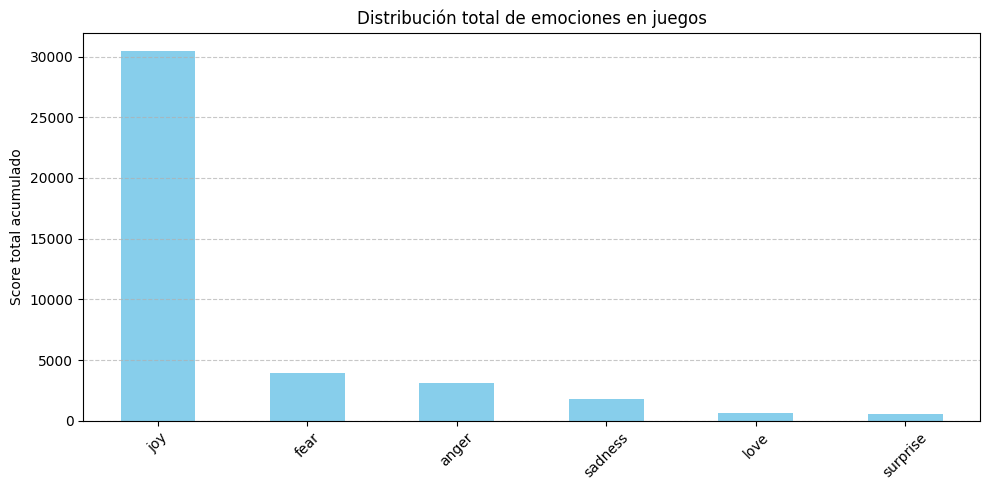

In [ ]:
import matplotlib.pyplot as plt

emociones = ['love', 'fear', 'joy', 'sadness', 'surprise', 'anger']
conteo_emociones = games_sample[emociones].sum().sort_values(ascending=False)

print("Diversidad de emociones:\n", conteo_emociones)

plt.figure(figsize=(10, 5))
conteo_emociones.plot(kind='bar', color='skyblue')
plt.title("Distribución total de emociones en juegos")
plt.ylabel("Score total acumulado")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Aquí se genera un prompt genérico, que se pasa por el mismo modelo para luego hacer similitud de coseno entre vectores, a ver cuales se parecen.

In [ ]:
user_prompt = "i want to play a videogame with a sad history"
prompt_emotions = get_emotions_transformers(user_prompt)
print(prompt_emotions)

{'sadness': 0.9974263310432434, 'joy': 0.0008545370656065643, 'love': 0.0007076626061461866, 'anger': 0.0005974951782263815, 'fear': 0.00026706766220740974, 'surprise': 0.00014679446758236736}


In [ ]:
emotion_cols = ['surprise', 'fear', 'love', 'sadness', 'anger', 'joy']

In [ ]:
games_emotions = games_sample[emotion_cols].fillna(0)

In [ ]:
games_emotions

,surprise,fear,love,sadness,anger,joy
27517,0.006902,0.080731,0.008446,0.031337,0.492294,0.380290
11242,0.004555,0.005077,0.013280,0.035328,0.170892,0.770867
24452,0.005601,0.014674,0.003918,0.007223,0.007173,0.961412
18917,0.009334,0.007720,0.002900,0.002264,0.002661,0.975120
17284,0.000267,0.000306,0.000382,0.001129,0.000305,0.997611
...,...,...,...,...,...,...
6265,0.002628,0.007943,0.001348,0.005462,0.008949,0.973670
11284,0.014332,0.644169,0.011065,0.140494,0.038737,0.151201
38158,0.000967,0.001245,0.001136,0.001682,0.000996,0.993975
860,0.031295,0.944489,0.005429,0.001264,0.008508,0.009014


In [ ]:
import numpy as np

# Vector ordenado con los mismos labels que en el DataFrame
prompt_vector = np.array([prompt_emotions.get(emotion, 0) for emotion in emotion_cols])
prompt_vector

array([1.46794468e-04, 2.67067662e-04, 7.07662606e-04, 9.97426331e-01,
       5.97495178e-04, 8.54537066e-04])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Matriz de juegos
game_vectors = games_emotions.values

# Similaridad
similarities = cosine_similarity([prompt_vector], game_vectors)[0]

In [ ]:
games_sample['emotion_match_score'] = similarities

In [ ]:
top_games = games_sample.sort_values('emotion_match_score', ascending=False).head(1000)
display(top_games[['title', 'emotion_match_score', 'surprise', 'fear', 'love', 'sadness', 'anger', 'joy']])

,title,emotion_match_score,surprise,fear,love,sadness,anger,joy
35097,Lie In My Heart,1.000000,0.000135,0.000197,0.000653,0.997356,0.000720,0.000939
33781,莫比乌斯之环-不属于任何人的交响悲歌-MOBIUS & ELEGY BELONGS TO N...,1.000000,0.000238,0.000375,0.000660,0.997632,0.000401,0.000694
34194,High School Otome,1.000000,0.000136,0.000531,0.000489,0.997300,0.000602,0.000942
34969,Inkslinger,1.000000,0.000202,0.000418,0.000391,0.997697,0.000469,0.000823
19677,罪印 Seal of sins,1.000000,0.000224,0.000481,0.000810,0.996933,0.000445,0.001107
...,...,...,...,...,...,...,...,...
1143,Necrosphere,0.949159,0.003615,0.035866,0.003186,0.695036,0.036868,0.225429
8095,HINGE VR,0.948950,0.004757,0.247027,0.001525,0.742672,0.001668,0.002352
10231,Milky Way Prince – The Vampire Star,0.948437,0.000956,0.004308,0.011573,0.717061,0.027611,0.238491
11399,Tinertia,0.948160,0.004373,0.165027,0.004649,0.649110,0.136682,0.040159


Se guarda el df completo con emociones de los juegos que tienen descripciones y tags.

In [ ]:
games_sample.to_csv('games_emotion.csv', index=False)

# NLP - all-mpnet-base-v2 (Enfoque descartado)


Este es un intento de NLP que más que usar emociones, era llevar las descripciones y prompts a embeddings y luego matchearlos. Además de que no se encontró plausible este enfoque, también genera df muy pesados al guardar los tensores de cada juego.

In [ ]:
import pandas as pd

In [ ]:
games_md = pd.read_csv("games_emotion.csv")

In [ ]:
games_md

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,tags,text,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score
0,2027350,Wanderer,2022-06-27,True,False,False,Positive,86,15,0.39,...,"['2D Fighter', '2D', 'Atmospheric', 'Adventure...",Wanderer. Wanderer is a top down action roguel...,"{'anger': 0.4922943413257599, 'joy': 0.3802896...",0.008446,0.080731,0.380290,0.031337,0.006902,0.492294,0.050921
1,313500,Blitzkrieg 2 Anthology,2014-09-16,True,False,False,Very Positive,84,927,4.99,...,"['Strategy', 'World War II', 'RTS', 'War', 'Mi...",Blitzkrieg 2 Anthology. Return to the bloody b...,"{'joy': 0.7708671689033508, 'anger': 0.1708921...",0.013280,0.005077,0.770867,0.035328,0.004555,0.170892,0.045669
2,1279910,NERF Legends,2021-11-18,True,False,False,Mostly Negative,35,34,49.99,...,"['Action', 'First-Person', 'FPS', 'Multiplayer...",NERF Legends. NERF Legends thrusts you into a ...,"{'joy': 0.9614120125770569, 'fear': 0.01467414...",0.003918,0.014674,0.961412,0.007223,0.005601,0.007173,0.008380
3,414160,Nubarron: The adventure of an unlucky gnome,2020-01-30,True,True,True,Mostly Positive,70,34,9.99,...,"['Adventure', 'Indie', 'Platformer', '2D', 'Pu...",Nubarron: The adventure of an unlucky gnome. G...,"{'joy': 0.975119948387146, 'surprise': 0.00933...",0.002900,0.007720,0.975120,0.002264,0.009334,0.002661,0.003186
4,511820,Le Havre: The Inland Port,2016-08-29,True,True,True,Mixed,53,26,6.99,...,"['Strategy', 'Indie', 'Casual', 'Board Game']",Le Havre: The Inland Port. Build a prosperous ...,"{'joy': 0.9976106882095337, 'sadness': 0.00112...",0.000382,0.000306,0.997611,0.001129,0.000267,0.000305,0.001989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40473,605230,Grey Hack,2017-12-14,True,True,True,Very Positive,90,985,19.99,...,"['Hacking', 'Simulation', 'Indie', 'Massively ...",Grey Hack. Grey Hack is a massively multiplaye...,"{'joy': 0.9736701250076294, 'anger': 0.0089492...",0.001348,0.007943,0.973670,0.005462,0.002628,0.008949,0.006475
40474,1256060,Cosmodread,2021-03-25,True,False,False,Very Positive,93,316,14.99,...,"['VR', 'Survival Horror', 'Action', 'Perma Dea...",Cosmodread. Cosmodread is a VR survival horror...,"{'fear': 0.6441690921783447, 'joy': 0.15120148...",0.011065,0.644169,0.151201,0.140494,0.014332,0.038737,0.207781
40475,41500,Torchlight,2009-10-27,True,True,False,Very Positive,91,4590,3.74,...,"['RPG', 'Action RPG', 'Hack and Slash', 'Dunge...",Torchlight. Adventure awaits in the award-winn...,"{'joy': 0.9939751029014587, 'sadness': 0.00168...",0.001136,0.001245,0.993975,0.001682,0.000967,0.000996,0.002551
40476,1081450,Criminal Dissidia,2022-09-27,True,False,False,Mixed,64,95,12.99,...,"['Action Roguelike', 'Card Battler', 'Turn-Bas...",Criminal Dissidia. Criminal Dissidia is a Rogu...,"{'fear': 0.9444889426231384, 'surprise': 0.031...",0.005429,0.944489,0.009014,0.001264,0.031295,0.008508,0.001627


In [ ]:
games_sample = games_md.sample(n=40478, random_state=42)
games_sample

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,tags,text,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score
27517,504400,Optika,2016-08-26,True,True,False,Very Positive,82,206,4.99,...,"['Casual', 'Indie', 'Adventure', 'Puzzle', 'Ph...",Optika. Discover the world of light physics: p...,"{'joy': 0.9951935410499573, 'surprise': 0.0012...",0.001163,0.000967,0.995194,0.000717,0.001279,0.000680,0.001579
11242,861930,Kidz,2018-07-26,True,True,False,Very Positive,85,271,0.00,...,"['Free to Play', 'Casual', 'Indie', 'Horror', ...","Kidz. Kidz is 2D Side Scrolling style, featuri...","{'joy': 0.9951732754707336, 'love': 0.00195837...",0.001958,0.000431,0.995173,0.000869,0.001019,0.000549,0.001732
24452,1678050,Runic Relay: The Trials,2021-07-14,True,False,False,Positive,83,12,0.00,...,"['Action', 'Racing', 'Platformer', 'Precision ...",Runic Relay: The Trials. Speed Platforming wit...,"{'joy': 0.9919846653938293, 'fear': 0.00219082...",0.000941,0.002191,0.991985,0.001963,0.001006,0.001915,0.002839
18917,1944250,Hana no No ni Saku Utakata no,2022-04-22,True,False,False,Very Positive,96,183,29.99,...,"['Casual', 'Adventure', 'Visual Novel', 'Inter...",Hana no No ni Saku Utakata no. 《五色浮影绽放于花之海洋》是由...,"{'joy': 0.9769169688224792, 'sadness': 0.01000...",0.002995,0.003415,0.976917,0.010003,0.001400,0.005269,0.011102
17284,346810,Marble Age,2015-03-04,True,True,False,Very Positive,81,597,5.99,...,"['Indie', 'Singleplayer', 'Strategy', 'Surviva...",Marble Age. Turn-based historical simulation s...,"{'joy': 0.9834949374198914, 'anger': 0.0071477...",0.002016,0.002043,0.983495,0.004086,0.001212,0.007148,0.005018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,898590,Margonem,2019-02-20,True,False,False,Mixed,55,238,0.00,...,"['Tactical RPG', 'PvE', 'MMORPG', 'Turn-Based ...",Margonem. Addictive pixel-art MMORPG! Start pl...,"{'joy': 0.9950506091117859, 'love': 0.00211621...",0.002116,0.000323,0.995051,0.000705,0.000769,0.001036,0.001568
11284,885570,Nova-Life: Amboise,2019-04-22,True,False,False,Mostly Positive,77,577,0.00,...,"['Simulation', 'Indie', 'Action', 'Free to Pla...",Nova-Life: Amboise. Nova-Life: Amboise is a mu...,"{'anger': 0.9721128940582275, 'joy': 0.0143273...",0.002110,0.007580,0.014327,0.002313,0.001557,0.972113,0.002994
38158,1624760,Cardiac Unrest,2021-05-22,True,True,False,Mixed,61,18,0.00,...,"['Action', 'Shooter', 'Third-Person Shooter', ...",Cardiac Unrest. You're a Combat Exorcist taske...,"{'fear': 0.5626107454299927, 'joy': 0.28122740...",0.013812,0.562611,0.281227,0.023483,0.008237,0.110630,0.037467
860,1007940,Classic Jigsaw Puzzles,2019-01-17,True,False,False,Positive,80,20,4.99,...,"['Puzzle', 'Family Friendly', 'Relaxing', 'Min...",Classic Jigsaw Puzzles. Classic Jigsaw Puzzles...,"{'joy': 0.9982547163963318, 'love': 0.00055201...",0.000552,0.000211,0.998255,0.000447,0.000342,0.000194,0.001305


In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

model = SentenceTransformer('all-mpnet-base-v2')

games_sample['text_embedding'] = games_sample['text'].apply(
    lambda x: model.encode(x, convert_to_tensor=True, normalize_embeddings=True)
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
games_sample

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,text,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score,text_embedding
27517,504400,Optika,2016-08-26,True,True,False,Very Positive,82,206,4.99,...,Optika. Discover the world of light physics: p...,"{'joy': 0.9951935410499573, 'surprise': 0.0012...",0.001163,0.000967,0.995194,0.000717,0.001279,0.000680,0.001579,"[tensor(0.0418, device='cuda:0'), tensor(-0.06..."
11242,861930,Kidz,2018-07-26,True,True,False,Very Positive,85,271,0.00,...,"Kidz. Kidz is 2D Side Scrolling style, featuri...","{'joy': 0.9951732754707336, 'love': 0.00195837...",0.001958,0.000431,0.995173,0.000869,0.001019,0.000549,0.001732,"[tensor(0.0059, device='cuda:0'), tensor(0.007..."
24452,1678050,Runic Relay: The Trials,2021-07-14,True,False,False,Positive,83,12,0.00,...,Runic Relay: The Trials. Speed Platforming wit...,"{'joy': 0.9919846653938293, 'fear': 0.00219082...",0.000941,0.002191,0.991985,0.001963,0.001006,0.001915,0.002839,"[tensor(-0.0112, device='cuda:0'), tensor(-0.0..."
18917,1944250,Hana no No ni Saku Utakata no,2022-04-22,True,False,False,Very Positive,96,183,29.99,...,Hana no No ni Saku Utakata no. 《五色浮影绽放于花之海洋》是由...,"{'joy': 0.9769169688224792, 'sadness': 0.01000...",0.002995,0.003415,0.976917,0.010003,0.001400,0.005269,0.011102,"[tensor(0.0532, device='cuda:0'), tensor(-0.01..."
17284,346810,Marble Age,2015-03-04,True,True,False,Very Positive,81,597,5.99,...,Marble Age. Turn-based historical simulation s...,"{'joy': 0.9834949374198914, 'anger': 0.0071477...",0.002016,0.002043,0.983495,0.004086,0.001212,0.007148,0.005018,"[tensor(-0.0295, device='cuda:0'), tensor(0.02..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,898590,Margonem,2019-02-20,True,False,False,Mixed,55,238,0.00,...,Margonem. Addictive pixel-art MMORPG! Start pl...,"{'joy': 0.9950506091117859, 'love': 0.00211621...",0.002116,0.000323,0.995051,0.000705,0.000769,0.001036,0.001568,"[tensor(0.0087, device='cuda:0'), tensor(-0.01..."
11284,885570,Nova-Life: Amboise,2019-04-22,True,False,False,Mostly Positive,77,577,0.00,...,Nova-Life: Amboise. Nova-Life: Amboise is a mu...,"{'anger': 0.9721128940582275, 'joy': 0.0143273...",0.002110,0.007580,0.014327,0.002313,0.001557,0.972113,0.002994,"[tensor(-0.0033, device='cuda:0'), tensor(0.01..."
38158,1624760,Cardiac Unrest,2021-05-22,True,True,False,Mixed,61,18,0.00,...,Cardiac Unrest. You're a Combat Exorcist taske...,"{'fear': 0.5626107454299927, 'joy': 0.28122740...",0.013812,0.562611,0.281227,0.023483,0.008237,0.110630,0.037467,"[tensor(-0.0312, device='cuda:0'), tensor(-0.0..."
860,1007940,Classic Jigsaw Puzzles,2019-01-17,True,False,False,Positive,80,20,4.99,...,Classic Jigsaw Puzzles. Classic Jigsaw Puzzles...,"{'joy': 0.9982547163963318, 'love': 0.00055201...",0.000552,0.000211,0.998255,0.000447,0.000342,0.000194,0.001305,"[tensor(0.0332, device='cuda:0'), tensor(0.016..."


In [ ]:
# Embedding del prompt
prompt_embedding = model.encode("i want to play a horror game", convert_to_tensor=True)

In [ ]:
games_sample_horror = games_sample

In [ ]:
# Calcular similitud
games_sample_horror['similarity'] = games_sample['text_embedding'].apply(lambda emb: util.cos_sim(prompt_embedding, emb).item())

In [ ]:
games_sample_horror

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score,text_embedding,similarity
27517,504400,Optika,2016-08-26,True,True,False,Very Positive,82,206,4.99,...,"{'joy': 0.9951935410499573, 'surprise': 0.0012...",0.001163,0.000967,0.995194,0.000717,0.001279,0.000680,0.001579,"[tensor(0.0418, device='cuda:0'), tensor(-0.06...",0.170116
11242,861930,Kidz,2018-07-26,True,True,False,Very Positive,85,271,0.00,...,"{'joy': 0.9951732754707336, 'love': 0.00195837...",0.001958,0.000431,0.995173,0.000869,0.001019,0.000549,0.001732,"[tensor(0.0059, device='cuda:0'), tensor(0.007...",0.305573
24452,1678050,Runic Relay: The Trials,2021-07-14,True,False,False,Positive,83,12,0.00,...,"{'joy': 0.9919846653938293, 'fear': 0.00219082...",0.000941,0.002191,0.991985,0.001963,0.001006,0.001915,0.002839,"[tensor(-0.0112, device='cuda:0'), tensor(-0.0...",0.409829
18917,1944250,Hana no No ni Saku Utakata no,2022-04-22,True,False,False,Very Positive,96,183,29.99,...,"{'joy': 0.9769169688224792, 'sadness': 0.01000...",0.002995,0.003415,0.976917,0.010003,0.001400,0.005269,0.011102,"[tensor(0.0532, device='cuda:0'), tensor(-0.01...",0.163666
17284,346810,Marble Age,2015-03-04,True,True,False,Very Positive,81,597,5.99,...,"{'joy': 0.9834949374198914, 'anger': 0.0071477...",0.002016,0.002043,0.983495,0.004086,0.001212,0.007148,0.005018,"[tensor(-0.0295, device='cuda:0'), tensor(0.02...",0.379714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,898590,Margonem,2019-02-20,True,False,False,Mixed,55,238,0.00,...,"{'joy': 0.9950506091117859, 'love': 0.00211621...",0.002116,0.000323,0.995051,0.000705,0.000769,0.001036,0.001568,"[tensor(0.0087, device='cuda:0'), tensor(-0.01...",0.339616
11284,885570,Nova-Life: Amboise,2019-04-22,True,False,False,Mostly Positive,77,577,0.00,...,"{'anger': 0.9721128940582275, 'joy': 0.0143273...",0.002110,0.007580,0.014327,0.002313,0.001557,0.972113,0.002994,"[tensor(-0.0033, device='cuda:0'), tensor(0.01...",0.231752
38158,1624760,Cardiac Unrest,2021-05-22,True,True,False,Mixed,61,18,0.00,...,"{'fear': 0.5626107454299927, 'joy': 0.28122740...",0.013812,0.562611,0.281227,0.023483,0.008237,0.110630,0.037467,"[tensor(-0.0312, device='cuda:0'), tensor(-0.0...",0.396855
860,1007940,Classic Jigsaw Puzzles,2019-01-17,True,False,False,Positive,80,20,4.99,...,"{'joy': 0.9982547163963318, 'love': 0.00055201...",0.000552,0.000211,0.998255,0.000447,0.000342,0.000194,0.001305,"[tensor(0.0332, device='cuda:0'), tensor(0.016...",0.293462


In [ ]:
games_recommended = games_sample.sort_values(by='similarity', ascending=False)

In [ ]:
games_recommended.head(10)

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score,text_embedding,similarity
1266,1625080,Have a Nice Dream,2021-05-24,True,False,False,Very Positive,93,2832,0.00,...,"{'fear': 0.9238964915275574, 'surprise': 0.023...",0.017405,0.923896,0.016868,0.014038,0.023939,0.003853,0.015485,"[tensor(0.0100, device='cuda:0'), tensor(0.039...",0.689288
2148,2183730,The Gravehouse,2023-01-06,True,False,False,Mostly Positive,72,11,4.99,...,"{'fear': 0.9749371409416199, 'sadness': 0.0102...",0.002666,0.974937,0.002470,0.010249,0.005205,0.004473,0.010787,"[tensor(0.0116, device='cuda:0'), tensor(0.029...",0.673720
28497,2390860,Mine,2023-04-28,True,False,False,Mostly Positive,76,21,0.49,...,"{'fear': 0.9954751133918762, 'surprise': 0.001...",0.000505,0.995475,0.000877,0.000629,0.001497,0.001016,0.000902,"[tensor(-0.0196, device='cuda:0'), tensor(-0.0...",0.673218
26816,1786640,SPOOKWARE: Watch Party,2021-11-16,True,False,False,Very Positive,95,60,0.00,...,"{'joy': 0.5384684801101685, 'sadness': 0.16911...",0.151413,0.095765,0.538468,0.169115,0.013785,0.031454,0.286151,"[tensor(-0.0090, device='cuda:0'), tensor(-0.0...",0.663143
37805,270630,Haunt the House: Terrortown,2014-06-06,True,False,False,Very Positive,86,1418,4.99,...,"{'joy': 0.9385691285133362, 'fear': 0.04025756...",0.003839,0.040258,0.938569,0.006238,0.004429,0.006668,0.007515,"[tensor(-0.0054, device='cuda:0'), tensor(0.02...",0.661830
21028,727720,Found Horror Game 11.exe,2018-08-16,True,False,False,Mostly Positive,70,51,3.99,...,"{'fear': 0.6318349242210388, 'surprise': 0.306...",0.011248,0.631835,0.033637,0.002239,0.306373,0.014669,0.003553,"[tensor(0.0103, device='cuda:0'), tensor(0.044...",0.655477
38805,1704550,TEST RE,2022-04-28,True,False,False,Mostly Positive,72,97,0.00,...,"{'joy': 0.9766572713851929, 'fear': 0.00950206...",0.002876,0.009502,0.976657,0.003968,0.004948,0.002048,0.004926,"[tensor(0.0230, device='cuda:0'), tensor(-0.04...",0.653016
32851,747690,Sinister Halloween,2019-10-31,True,False,False,Very Positive,86,96,4.99,...,"{'anger': 0.6243933439254761, 'fear': 0.359396...",0.004133,0.359397,0.001790,0.007746,0.002541,0.624393,0.011410,"[tensor(0.0056, device='cuda:0'), tensor(-0.00...",0.651730
35367,1557880,Wood Killer,2021-06-23,True,False,False,Mostly Negative,20,10,0.99,...,"{'fear': 0.8873717188835144, 'anger': 0.077514...",0.002800,0.887372,0.010457,0.016978,0.004879,0.077515,0.019387,"[tensor(0.0038, device='cuda:0'), tensor(0.039...",0.650865
3302,896520,Stay Out of the House,2022-10-13,True,False,False,Very Positive,94,527,14.99,...,"{'fear': 0.40392786264419556, 'joy': 0.3737965...",0.006254,0.403928,0.373797,0.083941,0.017100,0.114980,0.148475,"[tensor(-0.0019, device='cuda:0'), tensor(0.02...",0.645295


In [ ]:
games_sample

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,...,emotion_scores,love,fear,joy,sadness,surprise,anger,emotion_match_score,text_embedding,similarity
27517,504400,Optika,2016-08-26,True,True,False,Very Positive,82,206,4.99,...,"{'joy': 0.9951935410499573, 'surprise': 0.0012...",0.001163,0.000967,0.995194,0.000717,0.001279,0.000680,0.001579,"[tensor(0.0418, device='cuda:0'), tensor(-0.06...",0.170116
11242,861930,Kidz,2018-07-26,True,True,False,Very Positive,85,271,0.00,...,"{'joy': 0.9951732754707336, 'love': 0.00195837...",0.001958,0.000431,0.995173,0.000869,0.001019,0.000549,0.001732,"[tensor(0.0059, device='cuda:0'), tensor(0.007...",0.305573
24452,1678050,Runic Relay: The Trials,2021-07-14,True,False,False,Positive,83,12,0.00,...,"{'joy': 0.9919846653938293, 'fear': 0.00219082...",0.000941,0.002191,0.991985,0.001963,0.001006,0.001915,0.002839,"[tensor(-0.0112, device='cuda:0'), tensor(-0.0...",0.409829
18917,1944250,Hana no No ni Saku Utakata no,2022-04-22,True,False,False,Very Positive,96,183,29.99,...,"{'joy': 0.9769169688224792, 'sadness': 0.01000...",0.002995,0.003415,0.976917,0.010003,0.001400,0.005269,0.011102,"[tensor(0.0532, device='cuda:0'), tensor(-0.01...",0.163666
17284,346810,Marble Age,2015-03-04,True,True,False,Very Positive,81,597,5.99,...,"{'joy': 0.9834949374198914, 'anger': 0.0071477...",0.002016,0.002043,0.983495,0.004086,0.001212,0.007148,0.005018,"[tensor(-0.0295, device='cuda:0'), tensor(0.02...",0.379714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,898590,Margonem,2019-02-20,True,False,False,Mixed,55,238,0.00,...,"{'joy': 0.9950506091117859, 'love': 0.00211621...",0.002116,0.000323,0.995051,0.000705,0.000769,0.001036,0.001568,"[tensor(0.0087, device='cuda:0'), tensor(-0.01...",0.339616
11284,885570,Nova-Life: Amboise,2019-04-22,True,False,False,Mostly Positive,77,577,0.00,...,"{'anger': 0.9721128940582275, 'joy': 0.0143273...",0.002110,0.007580,0.014327,0.002313,0.001557,0.972113,0.002994,"[tensor(-0.0033, device='cuda:0'), tensor(0.01...",0.231752
38158,1624760,Cardiac Unrest,2021-05-22,True,True,False,Mixed,61,18,0.00,...,"{'fear': 0.5626107454299927, 'joy': 0.28122740...",0.013812,0.562611,0.281227,0.023483,0.008237,0.110630,0.037467,"[tensor(-0.0312, device='cuda:0'), tensor(-0.0...",0.396855
860,1007940,Classic Jigsaw Puzzles,2019-01-17,True,False,False,Positive,80,20,4.99,...,"{'joy': 0.9982547163963318, 'love': 0.00055201...",0.000552,0.000211,0.998255,0.000447,0.000342,0.000194,0.001305,"[tensor(0.0332, device='cuda:0'), tensor(0.016...",0.293462


In [ ]:
games_sample.to_csv('games_emotion_and_embeddings.csv', index=False)